# Three-Qubit Equal Superposition

## 1. Problem Statement
Create a 3-qubit quantum circuit, apply a Hadamard gate to each qubit, measure all three qubits, execute the circuit for 8192 shots using Qiskit AerSimulator, and analyze the measurement distribution.

---

## 2. Theoretical Overview

### The Hadamard Gate ($H$)
The **Hadamard gate** is a fundamental single-qubit unitary gate that transforms computational basis states into orthogonal equal superpositions:

$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

Acting on individual basis states:
$$H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} = |+\rangle, \quad H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}} = |-\rangle$$

### Creating a 3-Qubit Equal Superposition
When applied to a 3-qubit system initialized in the ground state $|000\rangle = |0\rangle \otimes |0\rangle \otimes |0\rangle$, applying a Hadamard gate to each qubit corresponds to the tensor product operator $H^{\otimes 3}$:

$$|\psi\rangle = H^{\otimes 3}|000\rangle = (H|0\rangle) \otimes (H|0\rangle) \otimes (H|0\rangle)$$

$$|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \otimes \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \otimes \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$$

Expanding this tensor product yields an equal superposition of all $2^3 = 8$ computational basis states:

$$|\psi\rangle = \frac{1}{2\sqrt{2}} \sum_{x \in \{0,1\}^3} |x\rangle = \frac{1}{\sqrt{8}}(|000\rangle + |001\rangle + |010\rangle + |011\rangle + |100\rangle + |101\rangle + |110\rangle + |111\rangle)$$

### Theoretical Probabilities
Each basis state $|x\rangle$ has an identical probability amplitude $\frac{1}{\sqrt{8}}$. According to the **Born rule**, the probability of observing any given state upon measurement is:

$$P(x) = \left|\frac{1}{\sqrt{8}}\right|^2 = \frac{1}{8} = 0.125 \quad (12.5\%)$$

for each of the 8 states: `000`, `001`, `010`, `011`, `100`, `101`, `110`, and `111`.

---

## 3. Tools & Libraries Used
- **Qiskit**: Open-source quantum development kit for constructing, simulating, and running quantum circuits.
- **Qiskit Aer (`AerSimulator`)**: High-performance simulator backend for executing quantum circuits with realistic noise models or ideal shot sampling.
- **Matplotlib**: Python data visualization library used to render the bar chart of measurement distributions.

---

## 4. Expected Outcome
- **State Space**: 3 qubits produce $2^3 = 8$ possible computational basis states (`000`, `001`, `010`, `011`, `100`, `101`, `110`, `111`).
- **Expected Frequency**: Each state should occur approximately $\frac{1}{8}$ of the total 8192 measurements (theoretically, $\frac{8192}{8} = 1024$ counts per state).
- **Sampling Variation**: Due to pseudo-random quantum shot noise and finite sampling variation, the measured counts will naturally fluctuate around 1024 and will not necessarily be exactly equal.

### Step 1: Import Required Libraries
Import `QuantumCircuit` from Qiskit for circuit definition, `AerSimulator` from Qiskit Aer for simulation, and `matplotlib.pyplot` for visualization.

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_4088/2316665587.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


### Step 2: Construct the 3-Qubit Quantum Circuit
Initialize a quantum circuit with 3 qubits and 3 classical bits. Apply a Hadamard gate ($H$) to each qubit to generate an equal superposition across all 8 basis states, measure all three qubits into their corresponding classical bits, and display the circuit diagram.

In [2]:
shots = 8192

qc = QuantumCircuit(3,3)

qc.h(0)

qc.h(1)

qc.h(2)

qc.measure([0,1,2],[0,1,2])

print(qc.draw())

     ┌───┐┌─┐      
q_0: ┤ H ├┤M├──────
     ├───┤└╥┘┌─┐   
q_1: ┤ H ├─╫─┤M├───
     ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─╫──╫─┤M├
     └───┘ ║  ║ └╥┘
c: 3/══════╩══╩══╩═
           0  1  2 


### Step 3: Simulate Circuit Execution using AerSimulator
Instantiate the `AerSimulator` backend and execute the circuit for $N = 8192$ shots to sample measurement counts.

In [3]:
backend = AerSimulator()

counts = backend.run(qc,shots=shots).result().get_counts()

print(counts)

{'011': 997, '111': 981, '100': 1025, '110': 1091, '001': 1045, '101': 994, '010': 1039, '000': 1020}


### Step 4: Extract State Frequencies for All 8 Computational States
Generate all 8 three-bit binary strings (`000` to `111`) and retrieve their corresponding counts from the simulator results dictionary.

In [4]:
states = []

for i in range(8):

    states.append(format(i,'03b'))

frequency = []

for state in states:

    frequency.append(counts.get(state,0))

### Step 5: Visualize Measurement Distribution with a Bar Chart
Plot the measured count distribution across all 8 basis states using Matplotlib to visually inspect the uniformity of the superposition.

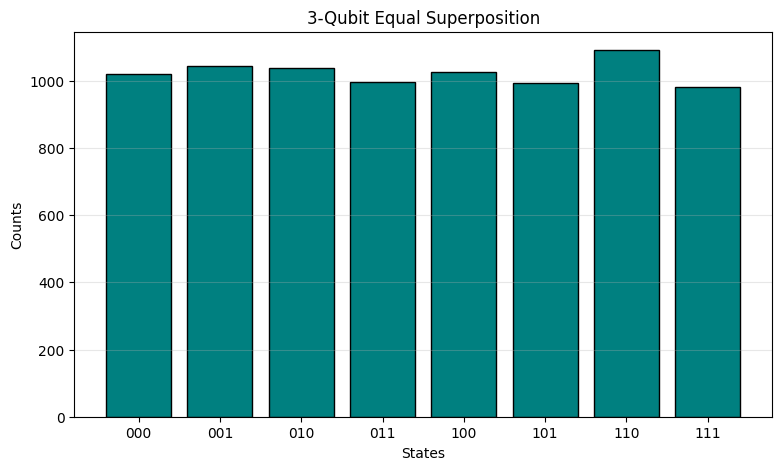

In [5]:
plt.figure(figsize=(9,5))

plt.bar(states,frequency,color='teal',edgecolor='black')

plt.title("3-Qubit Equal Superposition")

plt.xlabel("States")

plt.ylabel("Counts")

plt.grid(axis='y',alpha=0.3)

plt.show()

### Step 6: Verify Measured Probabilities against Theoretical Values
Compute the empirical probability ($P = \frac{\text{counts}}{\text{shots}}$) for each basis state and compare it directly to the theoretical probability ($1/8 = 0.1250$) in a structured verification table.

In [6]:
expected = 1/8

print("Verification Table\n")

print(f"{'State':<8}{'Measured':<12}{'Expected'}")

print("-"*35)

for state in states:

    probability = counts.get(state,0)/shots

    print(f"{state:<8}{probability:<12.4f}{expected:.4f}")

Verification Table

State   Measured    Expected
-----------------------------------
000     0.1245      0.1250
001     0.1276      0.1250
010     0.1268      0.1250
011     0.1217      0.1250
100     0.1251      0.1250
101     0.1213      0.1250
110     0.1332      0.1250
111     0.1198      0.1250


### Step 7: Programmatic Verification Summary
Print the final confirmation confirming that the measured frequencies closely align with theoretical predictions.

In [7]:
print("\nConclusion\n")

print("Every basis state has nearly equal probability.")

print("Measured probabilities are close to the theoretical value of 1/8.")


Conclusion

Every basis state has nearly equal probability.
Measured probabilities are close to the theoretical value of 1/8.


## Conclusion

- **Uniform 3-Qubit Superposition**: The experimental results confirm that applying a Hadamard gate to each of the three qubits successfully prepared the equal superposition state $|\psi\rangle = H^{\otimes 3}|000\rangle = \frac{1}{\sqrt{8}}\sum_{x=0}^7 |x\rangle$.
- **Close Alignment with Theory**: The measured probabilities for all 8 computational basis states (`000` through `111`) are tightly clustered around the theoretical probability of $\frac{1}{8} = 0.125$ ($12.5\%$), ranging between $0.1198$ and $0.1332$.
- **Demonstration of Quantum Uniformity**: The observed counts (each close to the expected mean of $\frac{8192}{8} = 1024$ shots) demonstrate an approximately uniform probability distribution across all $2^3 = 8$ computational states, with minor deviations fully consistent with expected statistical shot noise in finite sampling ($N = 8192$).